In [31]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sarthaktandulje/disaster-damage-5class")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/sarthaktandulje/disaster-damage-5class


In [32]:
# Install required libraries
!pip install -q ultralytics transformers accelerate bitsandbytes gradio kagglehub matplotlib

Dataset downloaded to: /kaggle/input/datasets/sarthaktandulje/disaster-damage-5class

Found 6 classes: ['flood', 'smoke', 'normal', 'fire', 'landslide', 'earthquake']
Created an Evaluation Set of 30 images for pipeline testing.


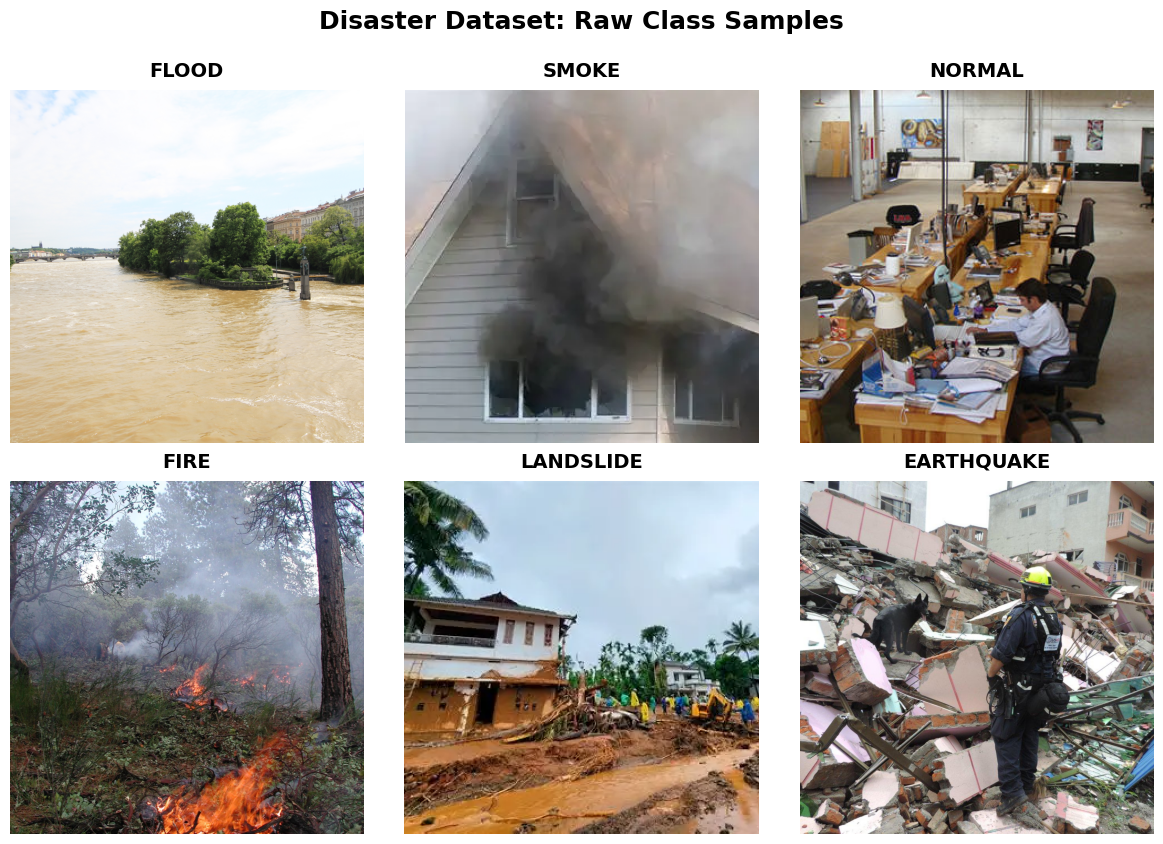

In [33]:
import kagglehub
import os
import glob
import random
import math
import matplotlib.pyplot as plt
from PIL import Image

print("Downloading dataset...")
# Download the dataset using the path you provided
dataset_path = kagglehub.dataset_download("sarthaktandulje/disaster-damage-5class")
print(f"Dataset downloaded to: {dataset_path}")

# Group images by their class (folder name)
image_paths = glob.glob(os.path.join(dataset_path, "**", "*.jpg"), recursive=True) 
image_paths += glob.glob(os.path.join(dataset_path, "**", "*.png"), recursive=True)

dataset_dict = {}
for path in image_paths:
    class_name = os.path.basename(os.path.dirname(path))
    if class_name not in dataset_dict:
        dataset_dict[class_name] = []
    dataset_dict[class_name].append(path)

print(f"\nFound {len(dataset_dict)} classes: {list(dataset_dict.keys())}")

# --- SPLITTING ---
evaluation_set = []
for class_name, paths in dataset_dict.items():
    sampled_paths = random.sample(paths, min(5, len(paths))) 
    evaluation_set.extend([(path, class_name) for path in sampled_paths])

print(f"Created an Evaluation Set of {len(evaluation_set)} images for pipeline testing.")

# --- UPGRADED VISUALIZATION (EDA) ---
num_classes = len(dataset_dict)
cols = 3
rows = math.ceil(num_classes / cols)

# Create a clean grid
fig, axes = plt.subplots(rows, cols, figsize=(12, 4 * rows))
axes = axes.flatten() # Flatten to easily iterate over the grid

for i, class_name in enumerate(dataset_dict.keys()):
    img_path = random.choice(dataset_dict[class_name])
    img = Image.open(img_path).convert("RGB")
    
    # Center-crop the image to make it a uniform square
    width, height = img.size
    new_size = min(width, height)
    left = (width - new_size)/2
    top = (height - new_size)/2
    right = (width + new_size)/2
    bottom = (height + new_size)/2
    img_cropped = img.crop((left, top, right, bottom))
    
    # Plot the cropped image
    axes[i].imshow(img_cropped)
    axes[i].set_title(class_name.upper(), fontsize=14, fontweight='bold', pad=10)
    axes[i].axis('off')

# Hide any unused subplots (if you had, say, 5 classes in a 6-slot grid)
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.suptitle("Disaster Dataset: Raw Class Samples", fontsize=18, fontweight='bold', y=1.05)
plt.show()

In [34]:
import torch
from ultralytics import YOLO
from transformers import BlipProcessor, BlipForConditionalGeneration
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline, BitsAndBytesConfig

print("Loading AI Architectures to GPU...")
device = "cuda" if torch.cuda.is_available() else "cpu"

# 1. YOLOv8
yolo_model = YOLO('yolov8n.pt') 

# 2. BLIP 
blip_processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-large")
blip_model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-large").to(device)

# 3. THE UPGRADE: Qwen 2.5 3B (High-Logic LLM)
llm_id = "Qwen/Qwen2.5-3B-Instruct"

# We MUST quantize this larger model to 4-bit so it fits in Kaggle's memory alongside YOLO and BLIP
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16
)

tokenizer = AutoTokenizer.from_pretrained(llm_id)
llm_model = AutoModelForCausalLM.from_pretrained(
    llm_id, 
    quantization_config=bnb_config, 
    device_map="auto"
)

report_generator = pipeline(
    "text-generation", 
    model=llm_model, 
    tokenizer=tokenizer, 
    max_new_tokens=250,  # <-- INCREASED FOR MORE DESCRIPTIVE OUTPUTS
    temperature=0.2, 
    truncation=True
)

print("All models successfully loaded with 4-bit quantization!")

Loading AI Architectures to GPU...


Loading weights:   0%|          | 0/616 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForConditionalGeneration LOAD REPORT from: Salesforce/blip-image-captioning-large
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

All models successfully loaded with 4-bit quantization!


Testing Pipeline on Class: earthquake


Both `max_new_tokens` (=250) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


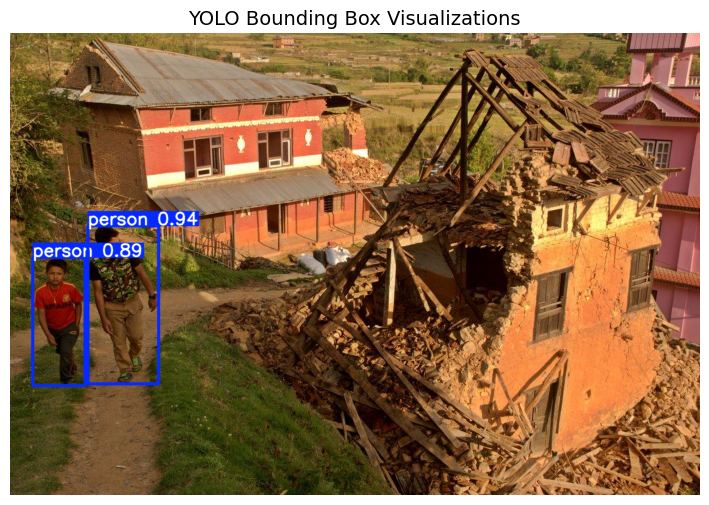

--- AI DIAGNOSTICS ---
YOLO Detected: person
BLIP Context: arafed building with a roof that has been torn down

--- GENERATED EMERGENCY REPORT ---
Assessment Report:
1. Scene Overview: 
The scene is located at an area near the Arafed building, where a significant incident involving a person was observed. The immediate surroundings include the Arafed building, which features a partially destroyeda roof that has been torn down, exposing the interior structure.

2. Detailed Damage and Hazards:

 (N/A)
usan't be  to is notvoduced Objectives:
 principally involve a princip to principally, principally principally principally principally principally principally principally principally principally principally principally principally principally principally principally principally principally principally principally principally principally principally principally principally principally principally principally principally principally principally principally principally principally principally p

In [35]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import random

def generate_disaster_report(img_path, visualize=False):
    # Load and preprocess image
    raw_image = Image.open(img_path).convert("RGB")
    
    # --- 1. YOLO INFERENCE (Micro-Hazard Detection) ---
    yolo_results = yolo_model(raw_image, verbose=False)
    
    # Extract annotated image (draws bounding boxes if objects are found)
    annotated_img_array = yolo_results[0].plot() 
    annotated_image = Image.fromarray(cv2.cvtColor(annotated_img_array, cv2.COLOR_BGR2RGB))
    
    # Extract object classes
    detected_classes = [yolo_model.names[int(c)] for c in yolo_results[0].boxes.cls]
    unique_objects = list(set(detected_classes))
    objects_str = ", ".join(unique_objects) if unique_objects else "No specific objects identified."

    # --- 2. VLM INFERENCE (BLIP Macro-Scene Context) ---
    vlm_inputs = blip_processor(raw_image, return_tensors="pt").to(device)
    vlm_outputs = blip_model.generate(**vlm_inputs)
    scene_description = blip_processor.decode(vlm_outputs[0], skip_special_tokens=True)

# --- 3. LLM INFERENCE (Qwen-3B Descriptive Synthesis) ---
    prompt = f"""<|im_start|>system
You are an expert disaster assessment analyst. Write a highly descriptive, formal damage report based strictly on the provided visual data. Do not invent objects or hazards that are not mentioned in the data.<|im_end|>
<|im_start|>user
Visual Data Input:
- YOLO Detected Objects: {objects_str}
- BLIP Scene Context: {scene_description}

Write a detailed assessment report using exactly these three headings:
1. Scene Overview
2. Identified Damage & Hazards
3. Recommended Actions<|im_end|>
<|im_start|>assistant
Assessment Report:
1. Scene Overview:"""
    
    # Generate the text
    llm_output = report_generator(prompt)
    generated_text = llm_output[0]['generated_text']
    
    # Clean up the output using Qwen's specific token markers
    raw_output = generated_text.split("<|im_start|>assistant")[-1].strip()
    
    # Fix the prefix to make it look clean in the UI
    if raw_output.startswith("Assessment Report:\n1. Scene Overview:"):
        final_report = raw_output
    elif raw_output.startswith("1. Scene Overview:"):
        final_report = "Assessment Report:\n" + raw_output
    else:
        final_report = "Assessment Report:\n1. Scene Overview: " + raw_output

    # --- 4. PIPELINE VISUALIZATION ---
    if visualize:
        plt.figure(figsize=(10, 6))
        plt.imshow(annotated_image)
        plt.axis('off')
        plt.title("YOLO Bounding Box Visualizations", fontsize=14)
        plt.show()
        
        print(f"--- AI DIAGNOSTICS ---")
        print(f"YOLO Detected: {objects_str}")
        print(f"BLIP Context: {scene_description}")
        print(f"\n--- GENERATED EMERGENCY REPORT ---")
        print(final_report)
        print("-" * 50)

    return annotated_image, objects_str, scene_description, final_report

# Test the pipeline on a random image from our Evaluation Set to ensure it works
test_img_path, true_class = random.choice(evaluation_set)
print(f"Testing Pipeline on Class: {true_class}")
_, _, _, _ = generate_disaster_report(test_img_path, visualize=True)

In [37]:
import gradio as gr

def gradio_interface(uploaded_image):
    temp_path = "gradio_temp.jpg"
    uploaded_image.save(temp_path)
    
    annotated_image, objects, scene, report = generate_disaster_report(temp_path, visualize=False)
    
    markdown_output = f"""
    ### 🔍 Pipeline Diagnostics
    **CNN (YOLO) Output:** {objects}
    **ViT (BLIP) Output:** {scene}
    
    ### 📄 Official Damage Report (LLM Output)
    {report}
    """
    return annotated_image, markdown_output

demo = gr.Interface(
    fn=gradio_interface,
    inputs=gr.Image(type="pil", label="Upload Disaster Imagery"),
    outputs=[
        gr.Image(type="pil", label="YOLO Object Detection Analysis"),
        gr.Markdown(label="AI Assessment Output")
    ],
    title="Multi-Modal Disaster Assessment Framework",
    description="Upload a post-disaster image. The system uses **YOLOv8** (CNN) for micro-hazard detection, **BLIP** (ViT) for macro-scene understanding, and **TinyLlama** (LLM) for report synthesis.",
    examples=[[path] for path, _ in random.sample(evaluation_set, 3)] 
)

demo.launch(share=True)

* Running on local URL:  http://127.0.0.1:7865
* Running on public URL: https://191bd3a0cfc9f29766.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


ERROR:    Exception in ASGI application
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/protocols/http/httptools_impl.py", line 416, in run_asgi
    result = await app(  # type: ignore[func-returns-value]
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/middleware/proxy_headers.py", line 60, in __call__
    return await self.app(scope, receive, send)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/fastapi/applications.py", line 1139, in __call__
    await super().__call__(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/applications.py", line 107, in __call__
    await self.middleware_stack(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/errors.py", line 186, in __call__
    raise exc
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/error